In [1]:
import sys
sys.path.append("../")

import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from src.evaluate import compute_metrics, print_report, plot_confusion_matrix

In [3]:
df_bal   = pd.read_csv("../data/balanced/preprocessed_tfidf.csv")
df_unbal = pd.read_csv("../data/unbalanced/preprocessed_tfidf.csv")
# Rename for clarity
df_bal   = df_bal.rename(columns={"review_tfidf": "text"})
df_unbal = df_unbal.rename(columns={"review_tfidf": "text"})

print("Balanced:  ", df_bal.shape)
print("Unbalanced:", df_unbal.shape)


Balanced:   (105630, 3)
Unbalanced: (328981, 3)


In [4]:
#train on balanced, test on full unbalanced
train_df, val_df = train_test_split(
    df_bal, test_size=0.2,
    stratify=df_bal["label"],
    random_state=42
)
test_df = df_unbal.copy()

print(f"Train:      {train_df.shape}")
print(f"Validation: {val_df.shape}")
print(f"Test:       {test_df.shape}  ← unbalanced, real-world distribution")


Train:      (84504, 3)
Validation: (21126, 3)
Test:       (328981, 3)  ← unbalanced, real-world distribution


In [5]:
# Fit ONLY on train set — never on val or test
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50_000,
    sublinear_tf=True
)

X_train = tfidf.fit_transform(train_df["text"])
X_val   = tfidf.transform(val_df["text"])
X_test  = tfidf.transform(test_df["text"])

y_train = train_df["label"].values
y_val   = val_df["label"].values
y_test  = test_df["label"].values

print(f"TF-IDF matrix shape: {X_train.shape}")

TF-IDF matrix shape: (84504, 50000)


In [6]:
lr = LogisticRegression(
    max_iter=1000,
    C=1.0,
    class_weight="balanced",  # important for the unbalanced test distribution
    random_state=42
)
lr.fit(X_train, y_train)
print("Training complete.")

Training complete.



  LR — Validation (Balanced) — Classification Report
              precision    recall  f1-score   support

    Negative       0.95      0.94      0.94     10564
    Positive       0.94      0.95      0.94     10562

    accuracy                           0.94     21126
   macro avg       0.94      0.94      0.94     21126
weighted avg       0.94      0.94      0.94     21126



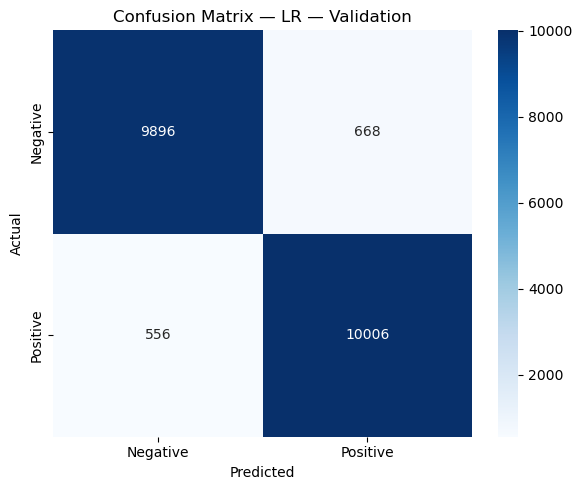

In [7]:
val_preds = lr.predict(X_val)
print_report(y_val, val_preds, "LR — Validation (Balanced)")
plot_confusion_matrix(y_val, val_preds, "LR — Validation")



  LR — Test (Unbalanced) [Experiment C] — Classification Report
              precision    recall  f1-score   support

    Negative       0.79      0.95      0.86     52819
    Positive       0.99      0.95      0.97    276162

    accuracy                           0.95    328981
   macro avg       0.89      0.95      0.92    328981
weighted avg       0.96      0.95      0.95    328981



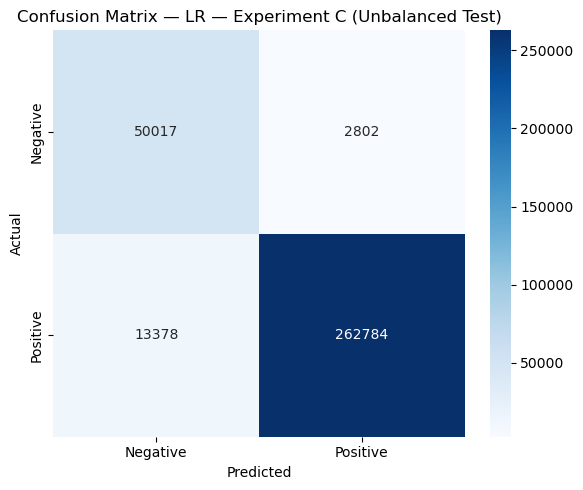


Experiment C Metrics:
  accuracy: 0.9508
  precision_weighted: 0.9573
  recall_weighted: 0.9508
  f1_weighted: 0.9526
  f1_negative: 0.8608
  f1_positive: 0.9701


In [8]:
test_preds = lr.predict(X_test)
test_proba = lr.predict_proba(X_test)[:, 1]

print_report(y_test, test_preds, "LR — Test (Unbalanced) [Experiment C]")
plot_confusion_matrix(
    y_test, test_preds,
    "LR — Experiment C (Unbalanced Test)",
    save_path="../data/cm_lr_experimentC.png"
)

metrics_lr = compute_metrics(y_test, test_preds, "TF-IDF + LR")
print("\nExperiment C Metrics:")
for k, v in metrics_lr.items():
    if k != "model":
        print(f"  {k}: {v:.4f}")


In [10]:
joblib.dump(tfidf, "../models/tfidf_vectorizer.joblib")
joblib.dump(lr,    "../models/lr_model.joblib")
print("Model saved to ../models/")

# Save metrics for comparison notebook
import json
with open("../models/metrics_lr.json", "w") as f:
    json.dump(metrics_lr, f)

Model saved to ../models/
